# Clasificación de Géneros Músicales usando Aprendizaje de Máquina basado en Caracteristicas Acústicas

## EDA y Preparación de los Datos General

## Descripción del Dataset

El dataset utilizado es Spotify Tracks DB (extraida de Kaggle), el cual contiene aproximadamente 232,000 canciones y sus respectivas métricas o caracteristicas. 


| Variable             | Descripción                                       |
| -------------------- | ------------------------------------------------- |
| **genre**            | Género musical de la canción (variable objetivo)  |
| **artist_name**      | Nombre del artista que interpreta la canción      |
| **track_name**       | Nombre de la canción                              |
| **track_id**         | Identificador único de la canción                 |
| **popularity**       | Nivel de popularidad de la canción (0–100)        |
| **acousticness**     | Medida de qué tan acústica es la canción (0 a 1)  |
| **danceability**     | Qué tan adecuada es la canción para bailar        |
| **duration_ms**      | Duración de la canción en milisegundos            |
| **energy**           | Intensidad y actividad de la canción              |
| **instrumentalness** | Probabilidad de que la canción sea instrumental   |
| **key**              | Tono musical en el que está la canción            |
| **liveness**         | Probabilidad de que la canción sea en vivo        |
| **loudness**         | Nivel de volumen en decibelios (dB)               |
| **mode**             | Modalidad de la canción (mayor = 1, menor = 0)    |
| **speechiness**      | Presencia de palabras habladas en la canción      |
| **tempo**            | Velocidad de la canción (BPM)                     |
| **time_signature**   | Compás musical (ej: 4/4)                          |
| **valence**          | Medida de positividad o “felicidad” de la canción |


### Imports necesarios

#### Imports para gestionar rutas y funciones especíicas

In [28]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [29]:
from src.features.clean import clean_columns

#### Imports para Manejo de Datos, Evaluación de Modelo y Visualización 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.cluster import KMeans,AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

### Carga del dataset 

In [31]:
df = pd.read_csv("../data/raw/SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


## Limpieza y Vista General del Dataset

Podemos observar que el dataset cuenta con 18 variables de las cuales:

- 11 variables númericas 
- 7 categoricas 

Adicionalmente la única variable que contiene nulos es track_name

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

#### Analisis de las Variables Cuantitativas 

- Podemos observar que todas las variables contienen una diferencia de escalas bastante altas. Variables como energy van de 0 a 1, mientras que variables como duration_ms llegan hasta 5.552917e+06. Así que para los modelos presentados se necesita la estandarización de los datos

- Cuando se analiza la variable instrumentalness podemos darnos cuenta que es una variable inmensamente sesgada, la media es apenas un aproximado de 0.14 y solo podemos alcanzar a ver valores altos en el tercer cuartil 

- Podemos observar que la variable contiene outliers grandes, ya que la media es 235,122 ms mientras que hay valores como el máximo que son de 5.5 millones de ms

In [33]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


#### Analisis Variable duration_ms

Para mirar mas a fondo la problematica de la variable duraction_ms graficamos la distribución y podemos observar que hay una gran concentración en los valores menor a 1,000,000 y un número muy reducido de los valores superiores, apenas se ve una pequeña linea. 

Entonces, se realizo un diagrama de barras para identificar la diferencia entre la cantidad de datos superiores e inferiores a 1,000,000. El diagrama nos muestra que la cantidad de valores superiores es muy insignificante, a penas 0,19% de los datos duran más que dicha cantidad.

Como dicha margen entre cantidades es tan alta y la cantidad inferior es insignificante quitamos esos datos para que el modelo pueda clasificar de mejor manera. Se vuelve a graficar la distribución y podemos observar que es mucho mas acampanado, es decir tiene una forma más normal que el inicial. 

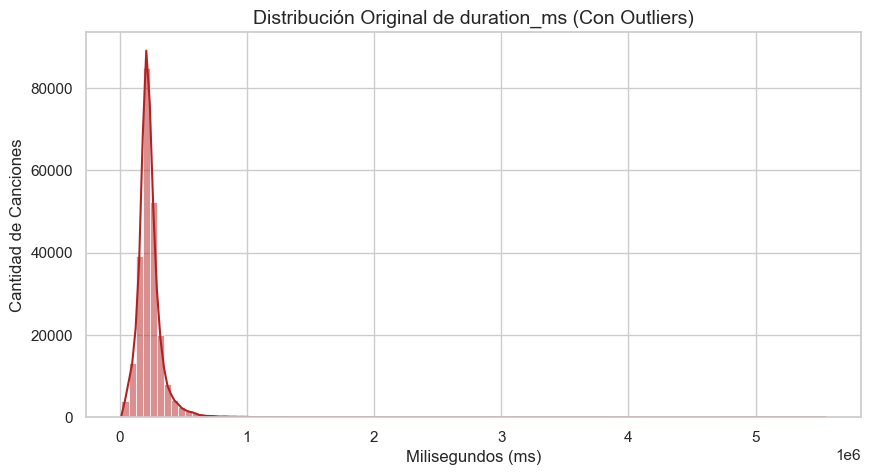

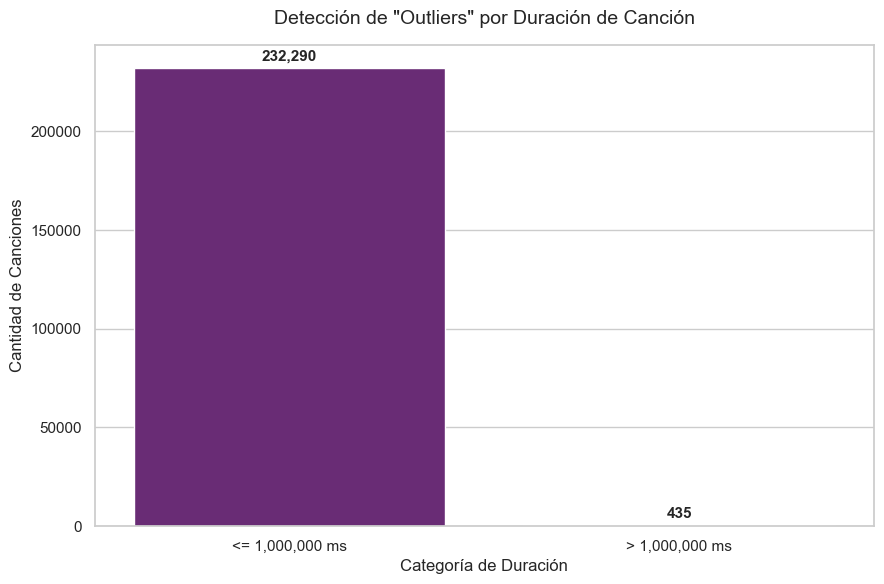

Las canciones de más de 1,000,000 ms representan el 0.19% del total.


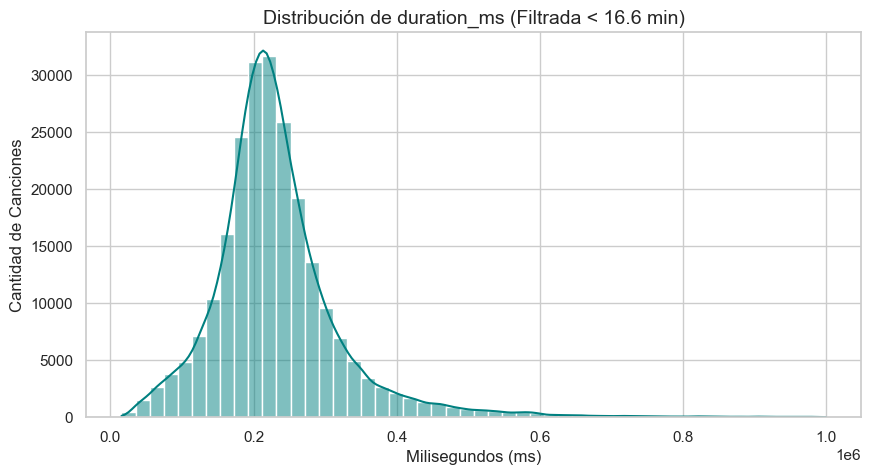

In [34]:
sns.set_theme(style="whitegrid")

# Distribucion de la duración 
plt.figure(figsize=(10, 5))
sns.histplot(df['duration_ms'], bins=100, kde=True, color='firebrick')
plt.title('Distribución Original de duration_ms (Con Outliers)', fontsize=14)
plt.xlabel('Milisegundos (ms)')
plt.ylabel('Cantidad de Canciones')
plt.show()


# Boxplot de la duración para detectar outliers
umbral = 1000000
df['es_muy_larga'] = df['duration_ms'] > umbral

conteo_duracion = df['es_muy_larga'].value_counts().rename({
    True: f'> {umbral:,} ms', 
    False: f'<= {umbral:,} ms'
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(x=conteo_duracion.index, y=conteo_duracion.values, palette='magma')

plt.title('Detección de "Outliers" por Duración de Canción', fontsize=14, pad=15)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xlabel('Categoría de Duración', fontsize=12)

for i, v in enumerate(conteo_duracion.values):
    ax.text(i, v + (max(conteo_duracion.values) * 0.01), f'{v:,}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

porcentaje = (conteo_duracion[f'> {umbral:,} ms'] / len(df)) * 100
print(f"Las canciones de más de 1,000,000 ms representan el {porcentaje:.2f}% del total.")

# 2. Distribución filtrada de duration (sin outliers)  
df_filtrado = df[df['duration_ms'] < 1000000]

plt.figure(figsize=(10, 5))
sns.histplot(df_filtrado['duration_ms'], bins=50, kde=True, color='teal')
plt.title('Distribución de duration_ms (Filtrada < 16.6 min)', fontsize=14)
plt.xlabel('Milisegundos (ms)')
plt.ylabel('Cantidad de Canciones')
plt.show()

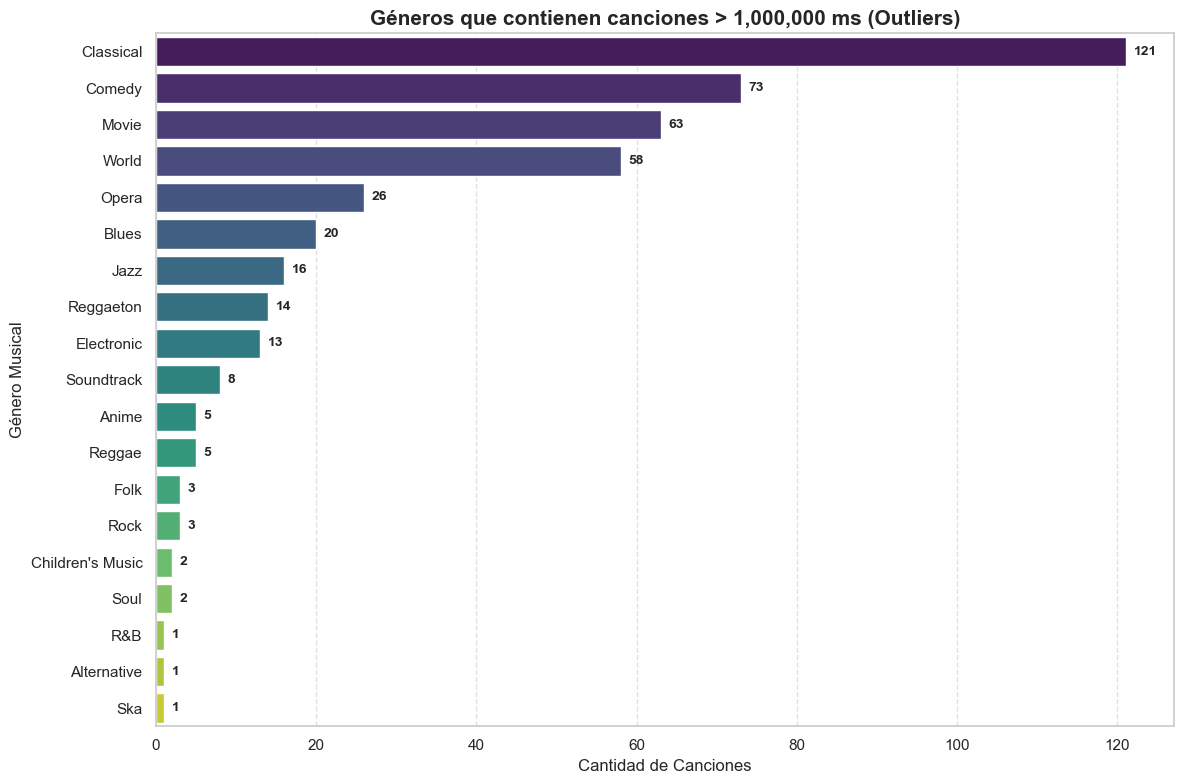

<Figure size 1200x700 with 0 Axes>

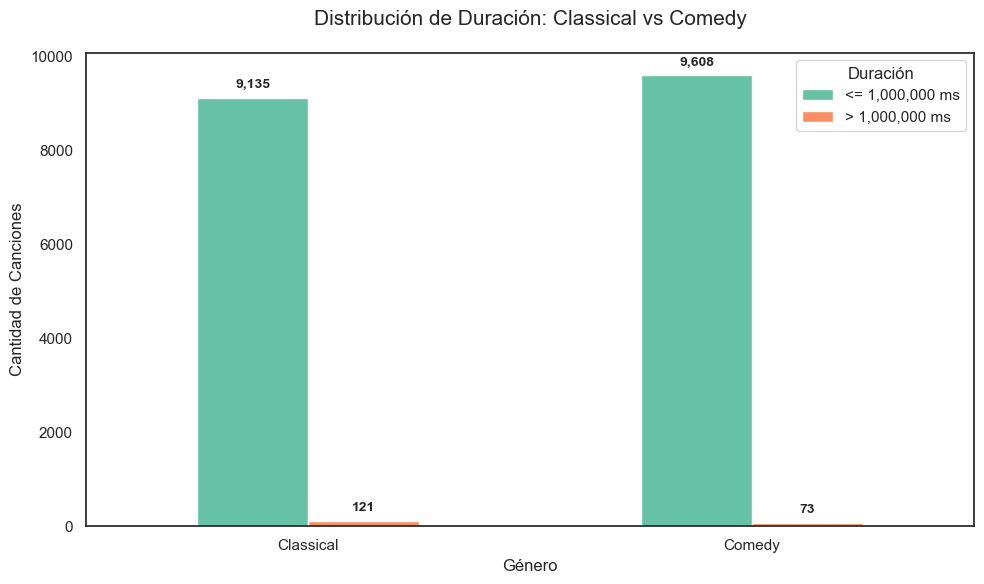

In [35]:
# Gráfico de barras para mostrar los géneros que contienen canciones con duración > 1,000,000 ms (outliers)

outliers = df[df['duration_ms'] > 1000000]
genre_counts = outliers['genre'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')

plt.title('Géneros que contienen canciones > 1,000,000 ms (Outliers)', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad de Canciones', fontsize=12)
plt.ylabel('Género Musical', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(genre_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# Grafico de barras comparando Classical y Comedy con la duración filtrada por el umbral de 1,000,000 ms

umbral = 1000000
total_dataset = len(df)

df_sub = df[df['genre'].isin(['Classical', 'Comedy'])]

df_sub['Categoria_Duracion'] = df_sub['duration_ms'].apply(
    lambda x: f'> {umbral:,} ms' if x > umbral else f'<= {umbral:,} ms'
)

stats = df_sub.groupby(['genre', 'Categoria_Duracion']).size().unstack(fill_value=0)
totales_genero = df['genre'].value_counts()

plt.figure(figsize=(12, 7))
sns.set_style("white")

ax = stats.plot(kind='bar', stacked=False, figsize=(10,6), color=['#66c2a5', '#fc8d62'])

plt.title('Distribución de Duración: Classical vs Comedy', fontsize=15, pad=20)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xlabel('Género', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Duración")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
df.isna().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
es_muy_larga        0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

### Cantidad de Valores en cada columna 

- Géneros como Música Infantil están separadas en dos variables diferentes lo que puede ser una inconcistencia en los datos,

- También podemos destacar que hay ocho valores con un beats de 0, lo cual no tiene sentido ya que no podemos tener una canción sin ningún beat. Así que los eliminaremos del modelo ya que son pocos. 

- Ademas podemos observar que las variables 'artist_name','track_name','track_id' son valores únicos asi que se borraran del analisis porque no ayudan al aprendizaje del modelo 

In [38]:
obj_dis_col=['genre','key','mode','time_signature']
for col in obj_dis_col:
    display(df[col].value_counts().reset_index())
    print('*'*50)

,genre,count
0,Comedy,9681
1,Soundtrack,9646
2,Indie,9543
3,Jazz,9441
4,Pop,9386
5,Electronic,9377
6,Children’s Music,9353
7,Folk,9299
8,Hip-Hop,9295
9,Rock,9272


**************************************************


,key,count
0,C,27583
1,G,26390
2,D,24077
3,C#,23201
4,A,22671
5,F,20279
6,B,17661
7,E,17390
8,A#,15526
9,F#,15222


**************************************************


,mode,count
0,Major,151744
1,Minor,80981


**************************************************


,time_signature,count
0,4/4,200760
1,3/4,24111
2,5/4,5238
3,1/4,2608
4,0/4,8


**************************************************


## Analisis Univariado

### Análisis Valores Categoricos 
La mayoría de las canciones están escritas en tonalidades simples como Do (C), Sol (G) y Re (D), lo que refleja la preferencia de los artistas por tonalidades fáciles y ampliamente accesibles.

El mode mayor predomina con casi el doble que el modo menor, lo que muestra que el mercado en general se inclina hacia ambientes musicales más brillantes y alegres.

Acapella es un género significativamente menor escuchado comparado con el resto de generos.

<Figure size 800x500 with 0 Axes>

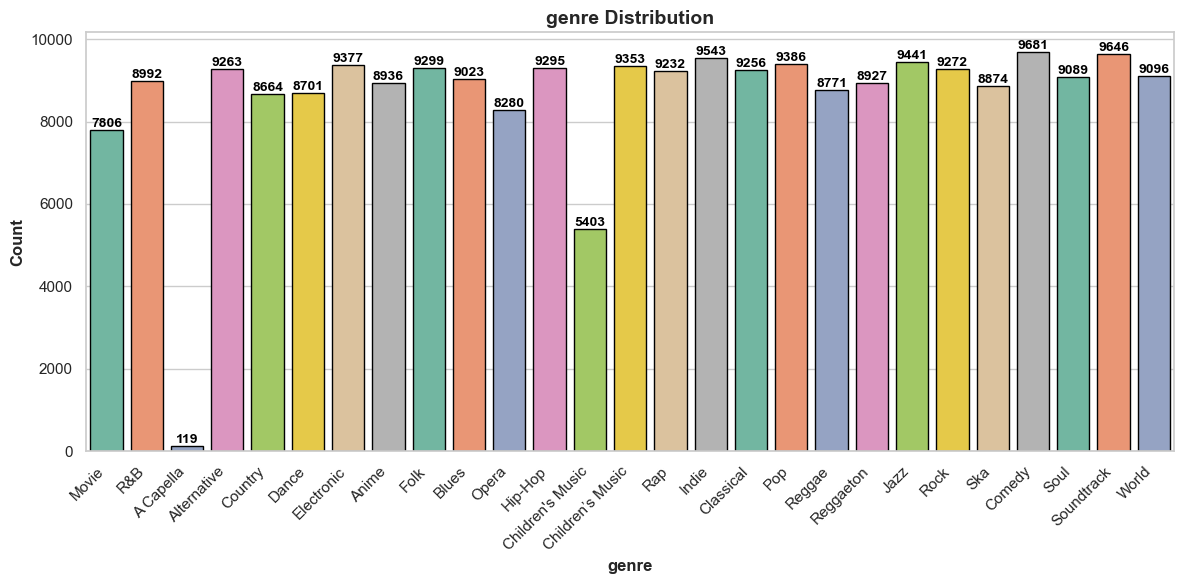

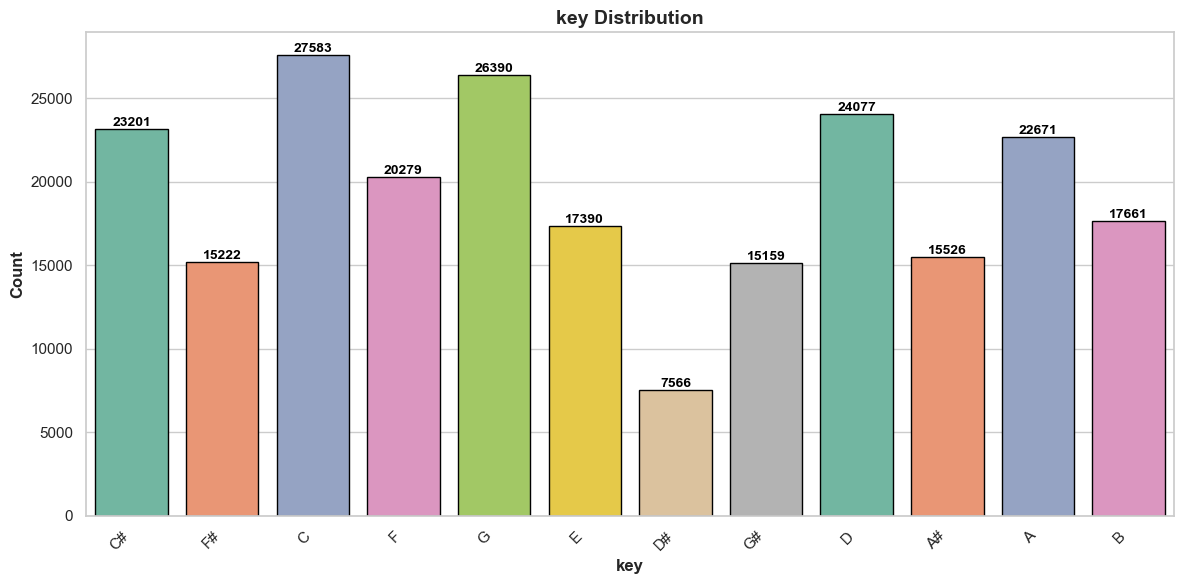

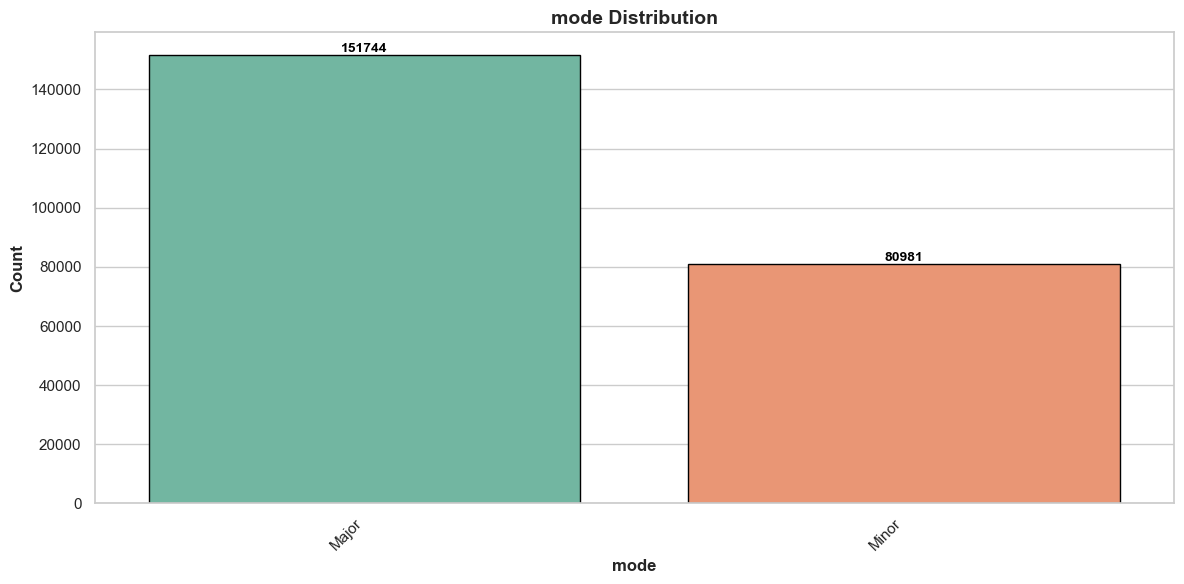

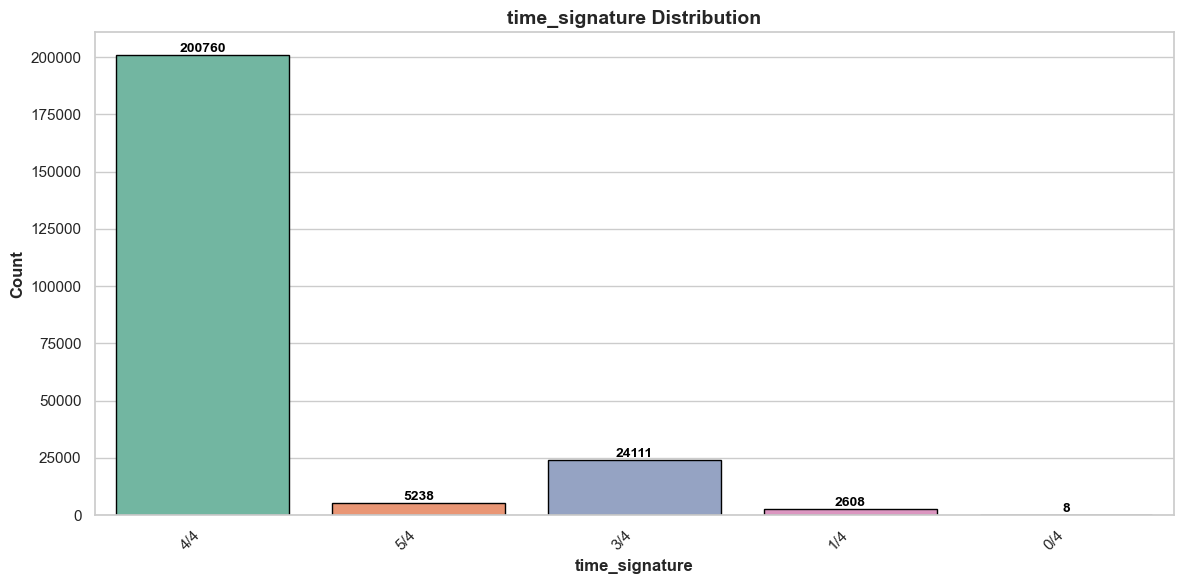

In [39]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(8, 5))

for col in obj_dis_col:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df, x=col, palette="Set2", edgecolor='black')
    
    plt.xlabel(col, fontsize=12, weight='bold')
    plt.ylabel("Count", fontsize=12, weight='bold')
    plt.title(f"{col} Distribution", fontsize=14, weight='bold')
    
    plt.xticks(rotation=45, ha='right')
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10, color='black', weight='bold')
    
    plt.tight_layout()
    plt.show()

### Analisis Variables Cuantitativas 

Podemos observar que las variables 'instrumentalness', 'speechiness', 'liveness' estan muy sesgadas. Entonces se hace un analisis con Skewness, Kurtosis y de la diferencia entre media y mediana para ver que tan sesgadas estaban y como se esperaba se pudo observar que en definitiva si estan altamente sesgadas.

In [40]:
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(8, 5))

for col in df.columns:
    if col not in obj_dis_col:
        plt.figure(figsize=(8, 5))
        ax = sns.histplot(data=df, x=col, palette="Set2", edgecolor='black')
        
        plt.xlabel(col, fontsize=12, weight='bold')
        plt.ylabel("Count", fontsize=12, weight='bold')
        plt.title(f"{col} Distribution", fontsize=14, weight='bold')
        
        plt.xticks(rotation=30, ha='right')
        
        plt.tight_layout()
        plt.show()

ValueError: 
Joey Bada$$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

Error in callback <function _draw_all_if_interactive at 0x000001FE99124E00> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
Joey Bada$$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

<Figure size 800x500 with 0 Axes>

ValueError: 
Joey Bada$$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

<Figure size 800x500 with 1 Axes>

In [ ]:
cols_sesgadas = ['instrumentalness', 'speechiness', 'liveness']

reporte_sesgo = pd.DataFrame({
    'Skewness (Asimetría)': df[cols_sesgadas].skew(),
    'Kurtosis': df[cols_sesgadas].kurt(),
    'Media': df[cols_sesgadas].mean(),
    'Mediana (50%)': df[cols_sesgadas].median()
})

reporte_sesgo['Diagnóstico'] = reporte_sesgo['Skewness (Asimetría)'].apply(
    lambda x: 'Sesgo Extremo' if abs(x) > 1 else 'Sesgo Moderado'
)

print(reporte_sesgo.round(4))

                  Skewness (Asimetría)  Kurtosis   Media  Mediana (50%)  \
instrumentalness                1.8198    1.5882  0.1483         0.0000   
speechiness                     3.3115   10.9862  0.1208         0.0501   
liveness                        2.0741    3.8880  0.2150         0.1280   

                    Diagnóstico  
instrumentalness  Sesgo Extremo  
speechiness       Sesgo Extremo  
liveness          Sesgo Extremo  


### Analisis Bivariado

1. **Matriz de Correlación**

- La variables 'energy' y 'loudness' tienen una correlación mayor a 0.8. Esto podria indicar que canciones con volumenes mas altos suelen ser más energicas.

- Las variables acousticness tienen una correlación negativa fuerte con 0.71

2. **Boxplots y ANOVA**

- Para ver que tan significativos son las variables con respecto a la variable genero se graficaron los boxplots y se hicieron pruebas ANOVA. Se pudo observar que son todos los p-values son igual a cero, diciendo que las diferencias son significativas entre los grupos. Pero tambien se puede ver que la variable con F-statistic más alto es speechiness, lo que podría indicar que es la variable que más podria ayudar a la clasificación del modelo. 
- Adicionalmente, se puede observar que la variable tempo es la que menos aporta al modelo, conun F1 score pequeño

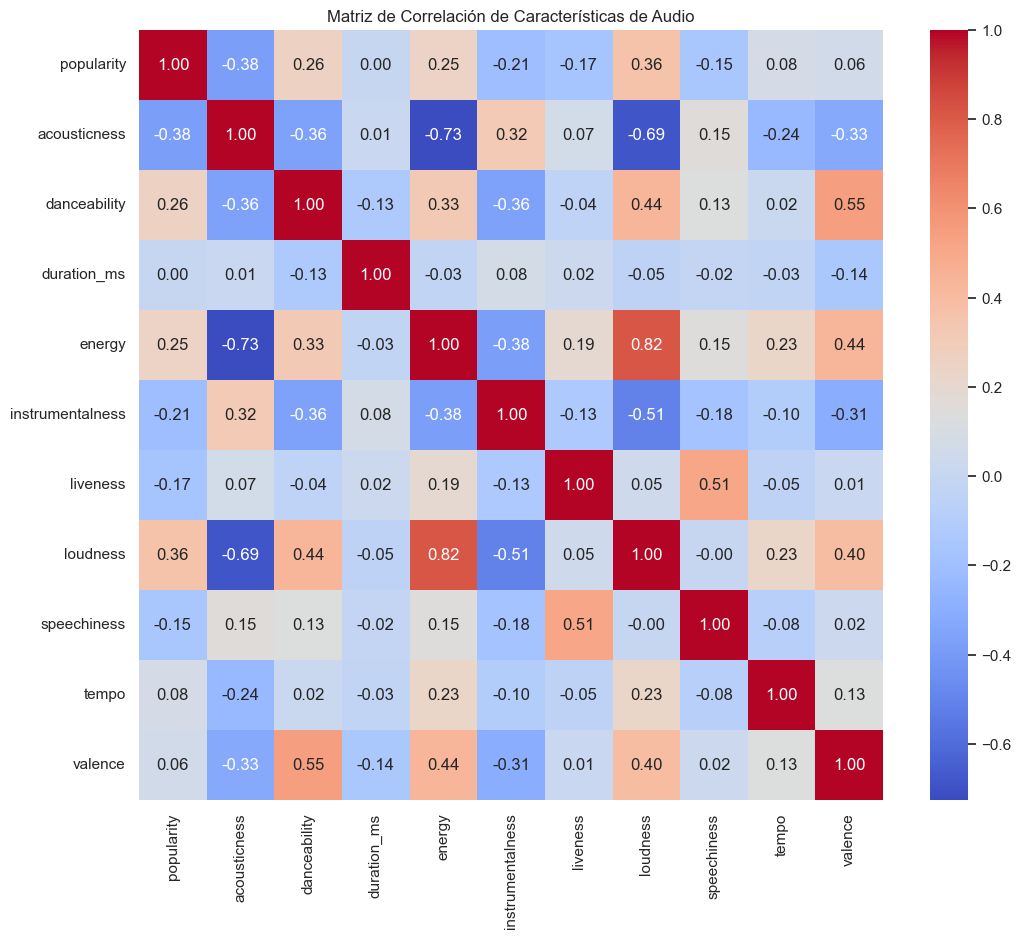

In [ ]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación de Características de Audio')
plt.show()

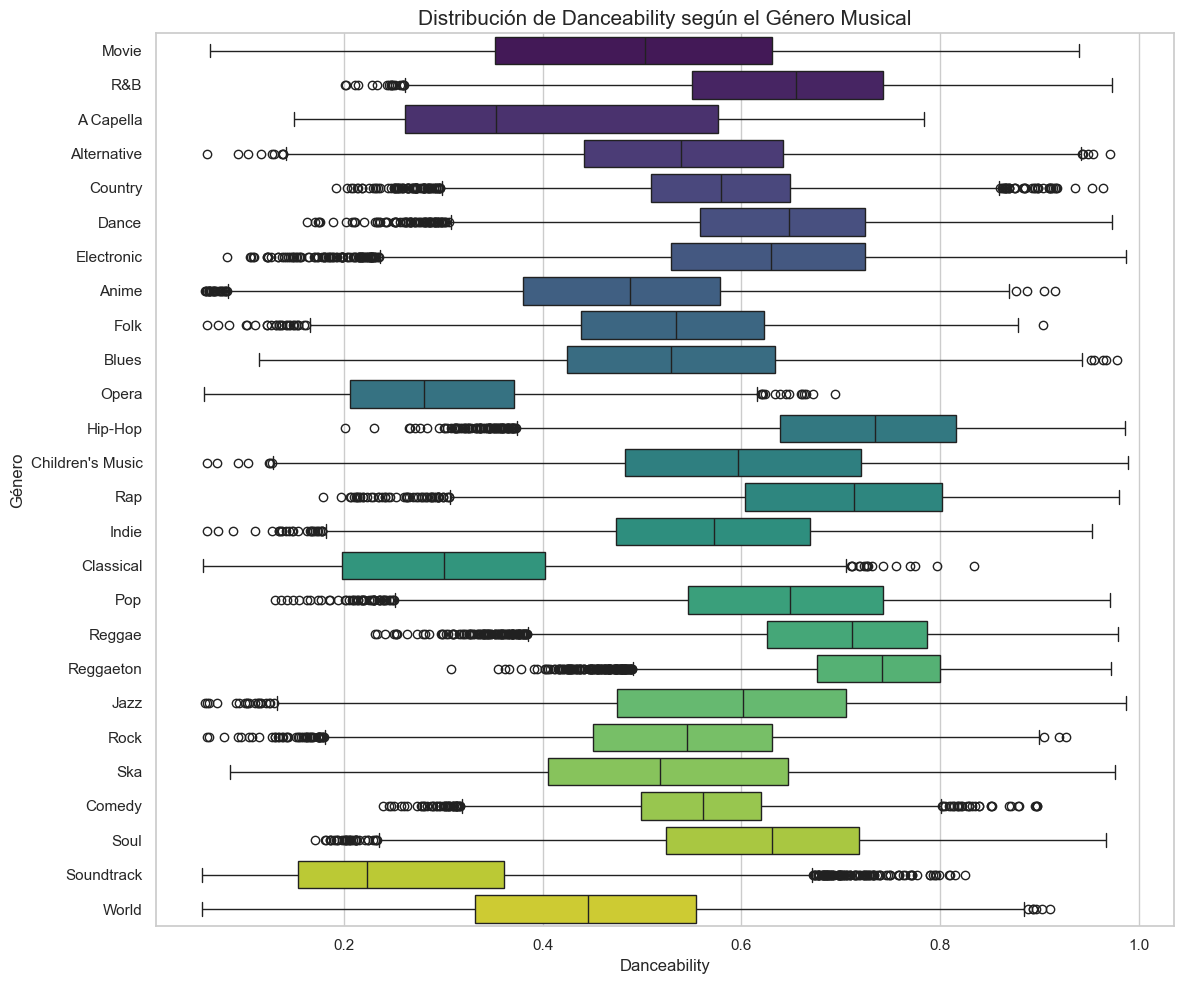

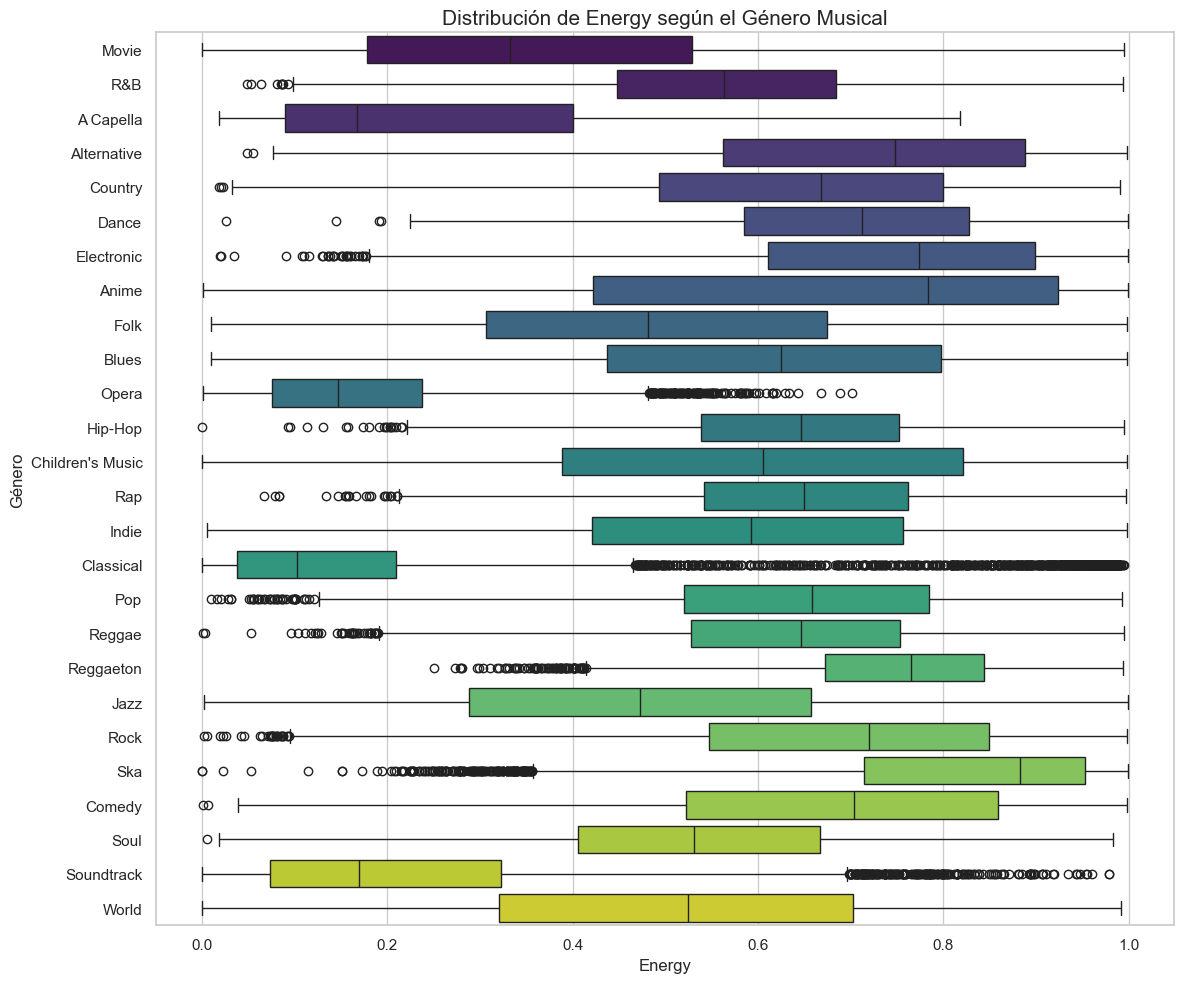

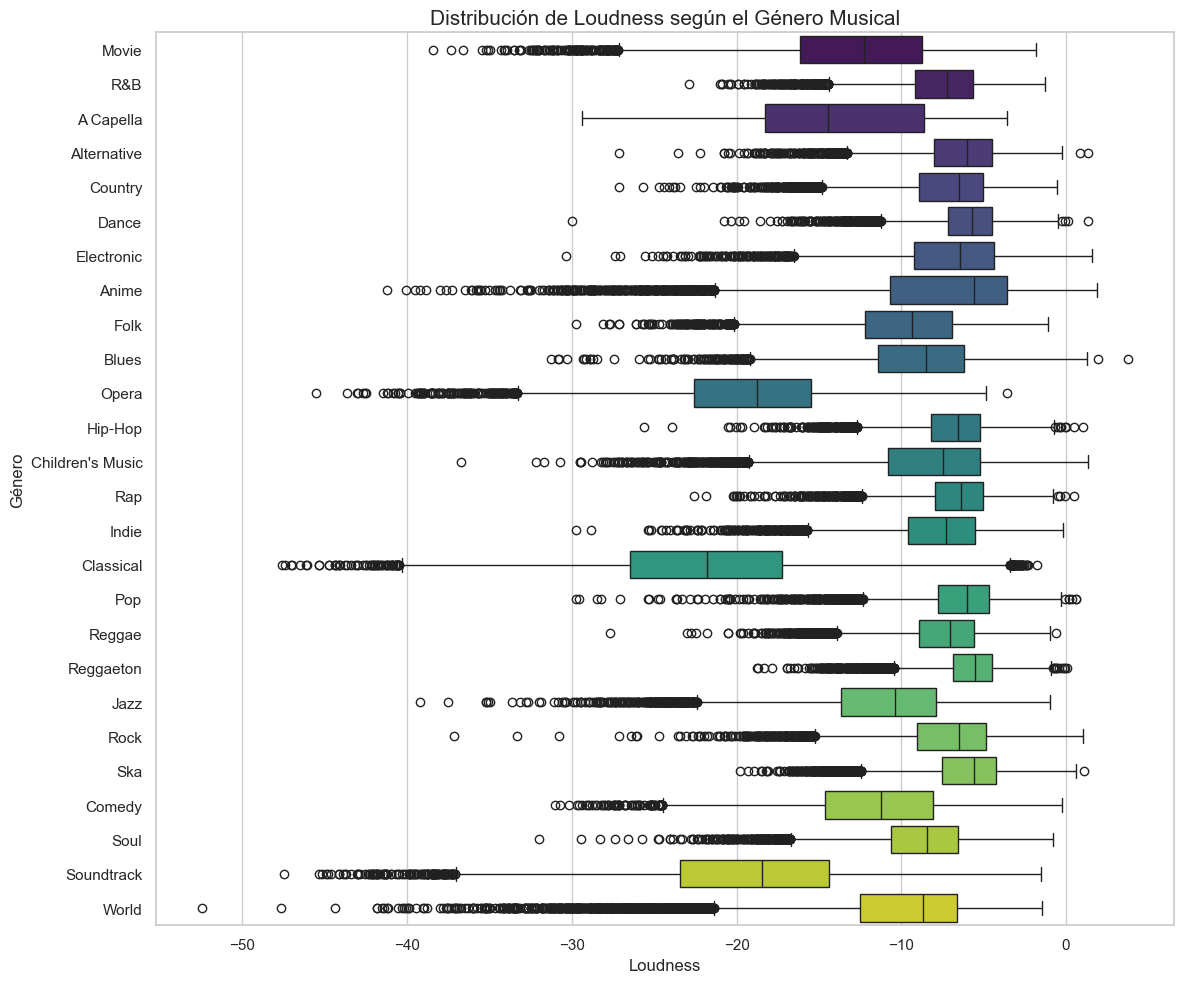

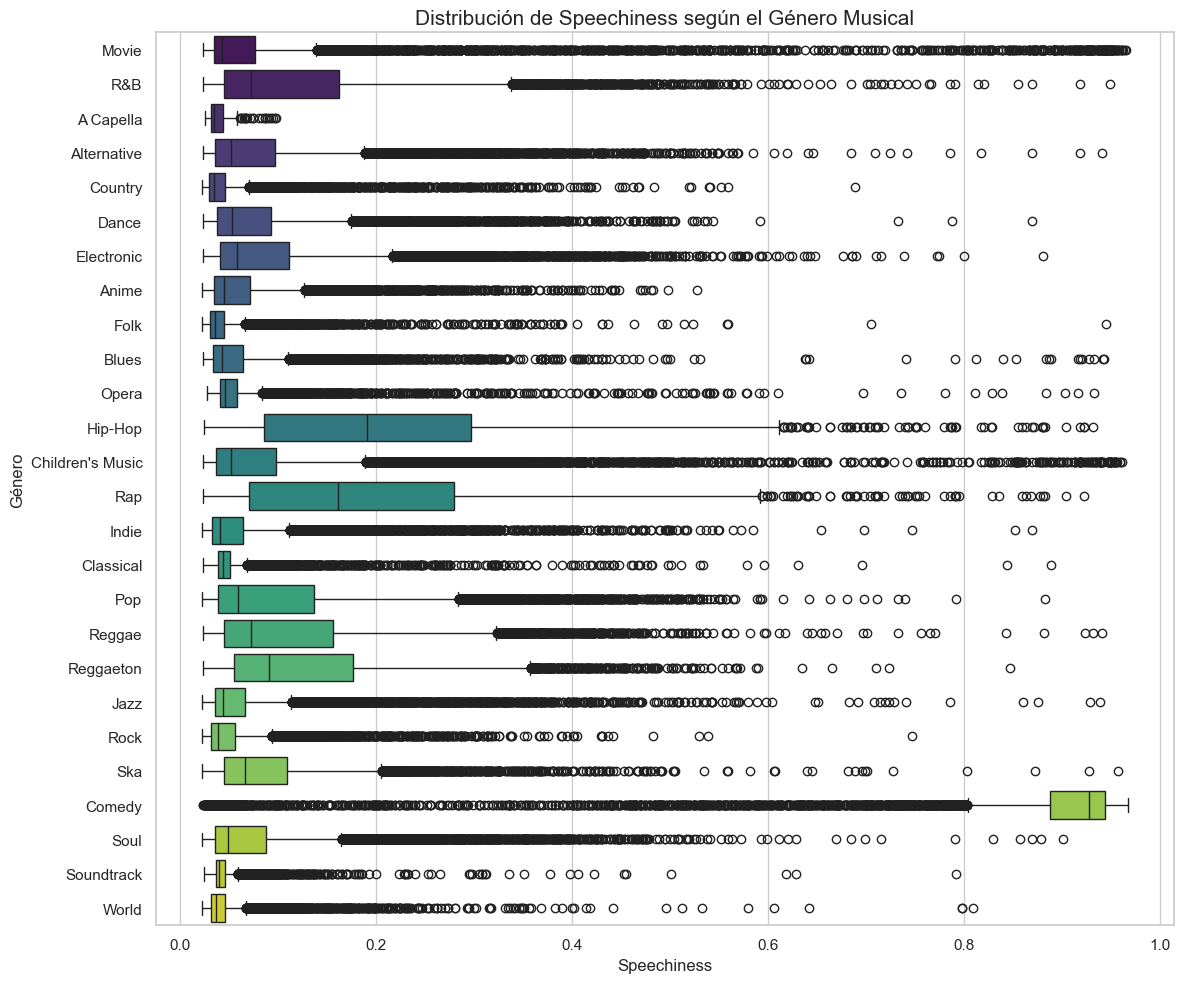

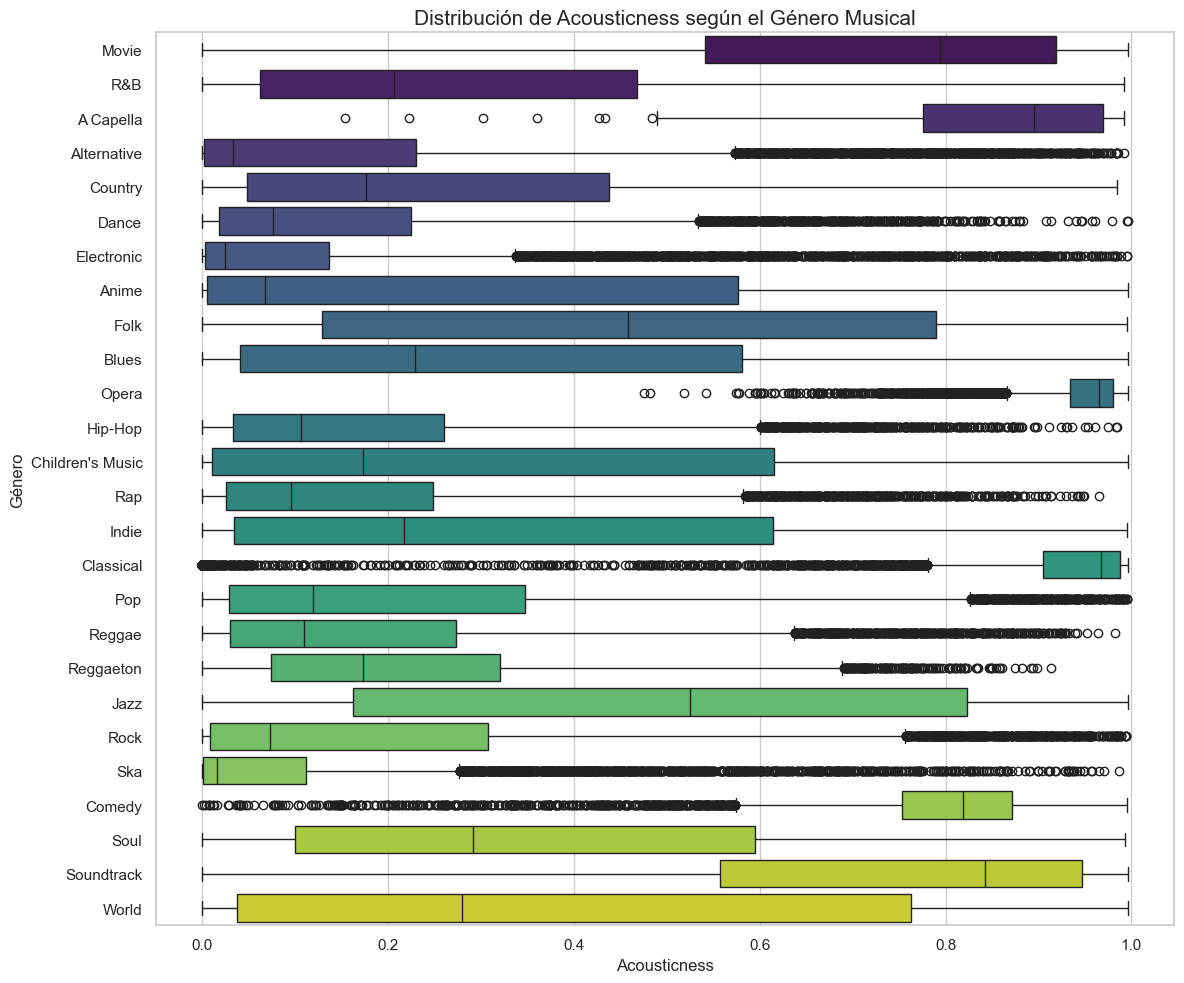

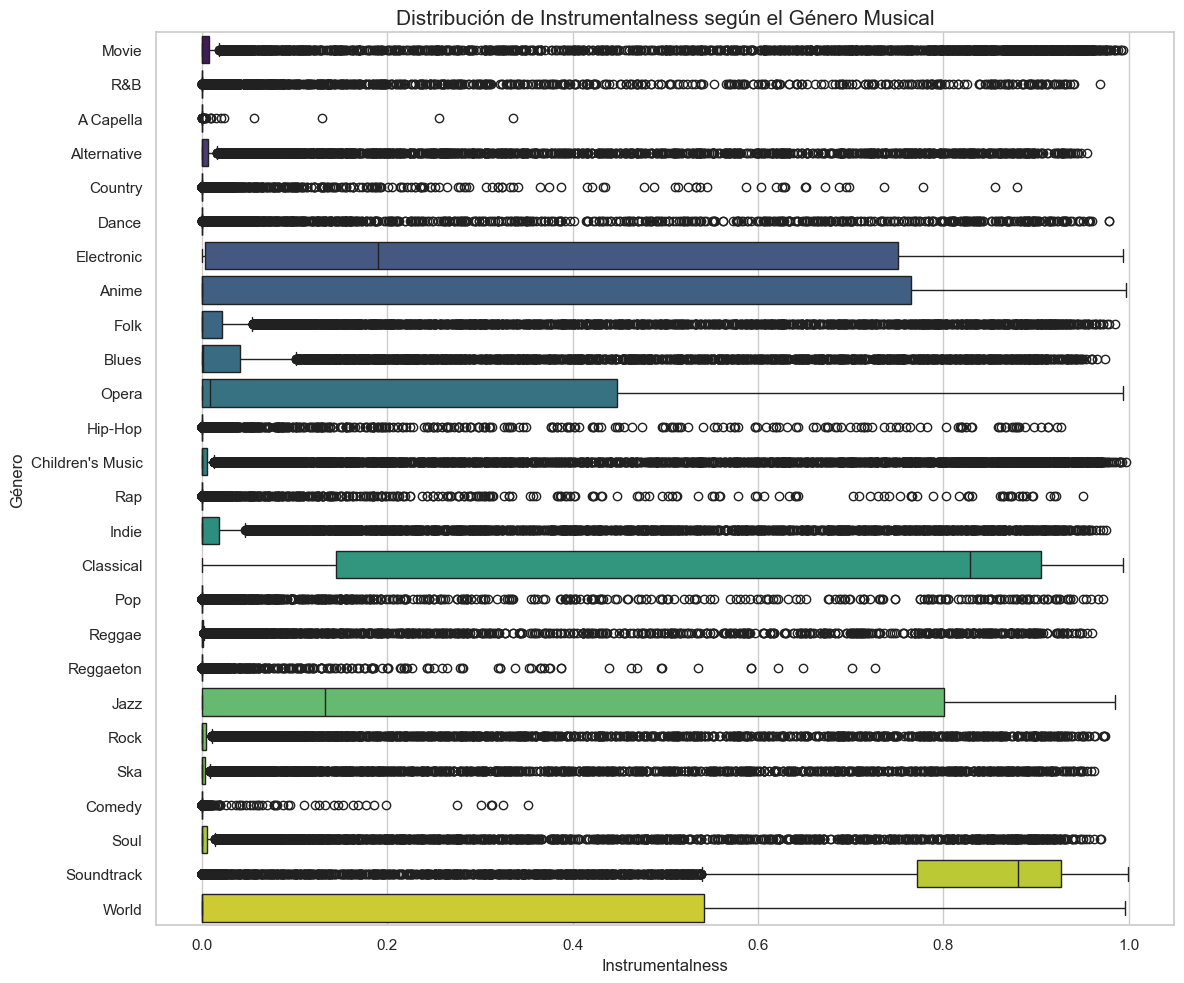

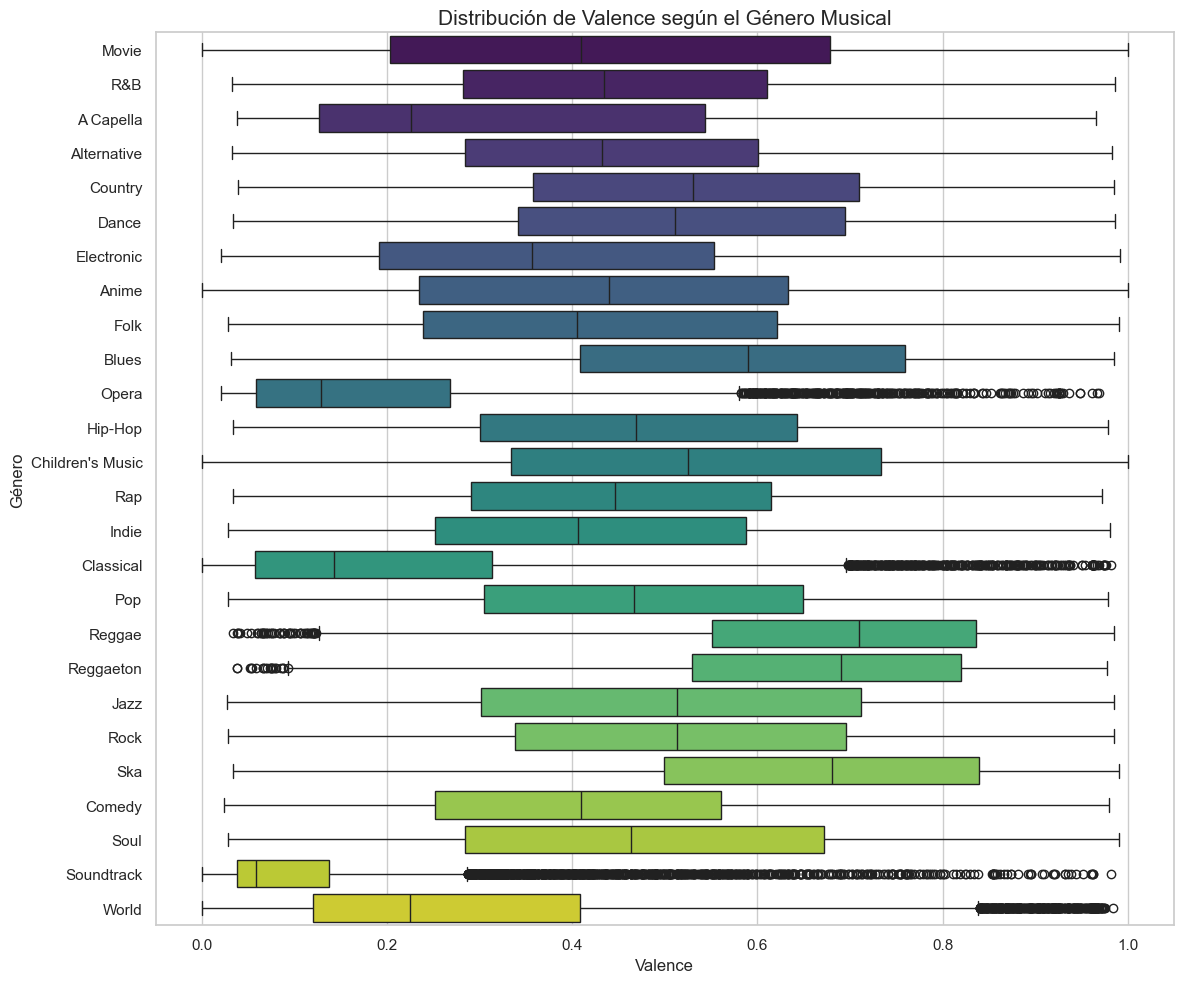

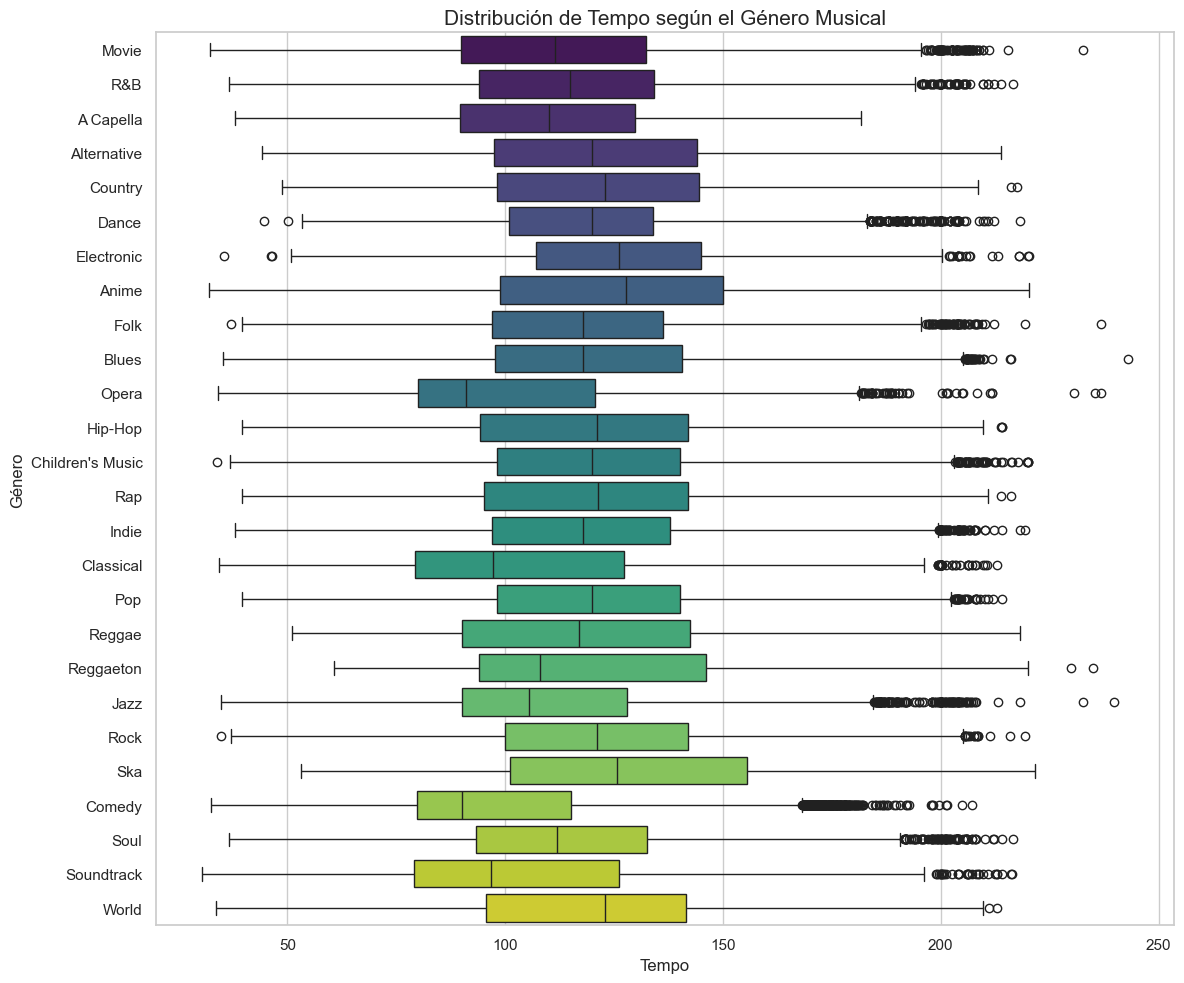

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables numéricas que queremos analizar
features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'valence', 'tempo'
]

# Bucle para crear un gráfico por cada característica
for feature in features:
    plt.figure(figsize=(12, 10))
    # Usamos diferentes paletas para variar visualmente
    sns.boxplot(data=df, x=feature, y='genre', palette='viridis')
    
    plt.title(f'Distribución de {feature.capitalize()} según el Género Musical', fontsize=15)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel('Género', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import f_oneway
import pandas as pd


variables_numericas = df.select_dtypes(include=['float64', 'int64']).columns
columnas_estudiar = [col for col in variables_numericas if col != 'duration_ms']

resultados_anova = []

print("--- Análisis de Varianza (ANOVA) por Género ---")

for var in columnas_estudiar:
    grupos = [df[df['genre'] == g][var].dropna() for g in df['genre'].unique()]
    
    f_stat, p_value = f_oneway(*grupos)
    
    resultados_anova.append({
        'Variable': var,
        'F-Statistic': f_stat,
        'p-value': p_value,
        'Significativo': 'Sí' if p_value < 0.05 else 'No'
    })

df_anova = pd.DataFrame(resultados_anova).sort_values(by='F-Statistic', ascending=False)
print(df_anova.to_string(index=False))

--- Análisis de Varianza (ANOVA) por Género ---
        Variable  F-Statistic  p-value Significativo
     speechiness 24401.255494      0.0            Sí
      popularity 14367.978305      0.0            Sí
        loudness  9158.808516      0.0            Sí
    acousticness  7499.239371      0.0            Sí
    danceability  6869.774531      0.0            Sí
instrumentalness  6479.598912      0.0            Sí
          energy  6156.146706      0.0            Sí
        liveness  4013.482107      0.0            Sí
         valence  3251.196678      0.0            Sí
           tempo   620.830997      0.0            Sí


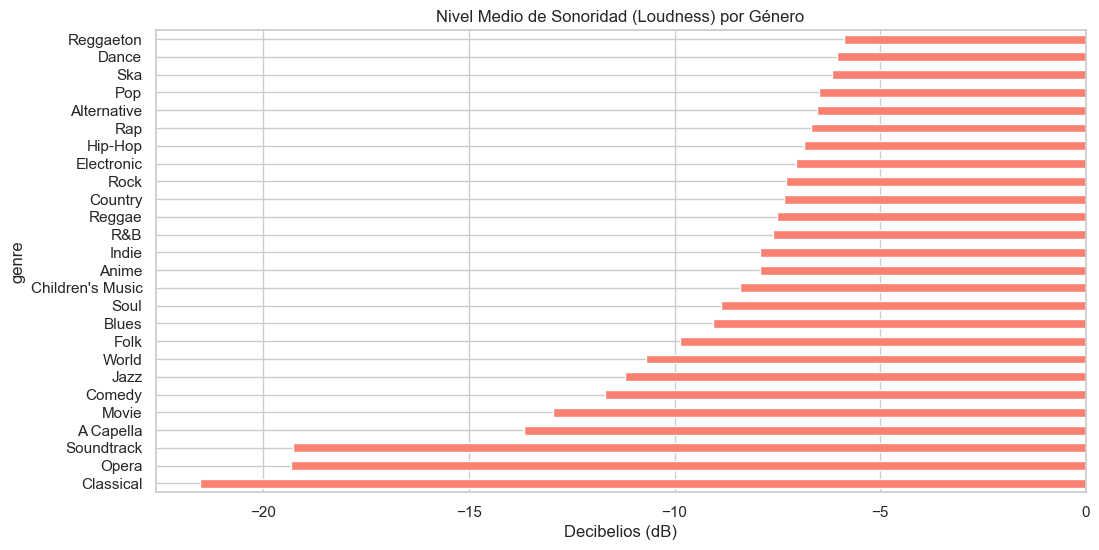

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby('genre')['loudness'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Nivel Medio de Sonoridad (Loudness) por Género')
plt.xlabel('Decibelios (dB)')
plt.show()

Toda la limpieza necesaria fue implementada en la funcion clean dentro del archivo src/features/clean.py 

In [43]:
# Guardar base de datos

output_dir = '../data/processed/'
output_file = os.path.join(output_dir, 'music_data_clean.csv')

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df_clean = clean_columns(df)
df_clean.to_csv(output_file, index=False)